## 1 PyTorch Workflow

In machine learning models is learn from the data using algorithm like neural network.

let's build model before we want to learn workflow of pytorch train.

*Steps :*
***
1. Get data into tensors.
2. Build or pick model.
3. --pick a loss function.
4. --build training loop.
5. fit the model to the data and make predictions.
6. Evaluate the model.
7. Improve model via experiment.
8. save and load model.
***

In [1]:
import torch 
from torch import nn

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
print(torch.__version__)

2.13.0+cpu


## 1. Data preparing and loading

In [2]:
# create a known parameters
weights = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weights * X + bias

## Split data

In Machine Learning datas are splited into 3 parts:

1. *Training Datasets -  60-80% datasets*  -- model learn from it
2. *Validation Datasets - 10-20% datasets* -- it is like sample test before enter the test
3. *Testing Datasets - 10-20% datasets *   -- it is for test data



In [3]:
# Now we use only train and test later use validation also

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    random_state=42,
                                                    test_size=0.2,
                                                    shuffle=False)

len(X_train), len(X_test), len(y_train), len(y_test)                                                  

(40, 10, 40, 10)

In [4]:
X_train[:10], y_train[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

## Visualize the data

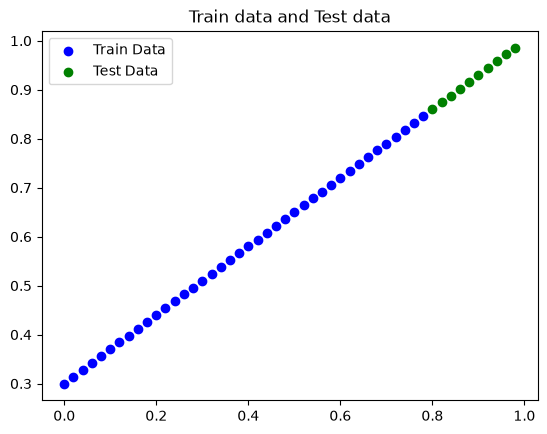

In [5]:
plt.scatter(X_train, y_train, c='b', label='Train Data')
plt.scatter(X_test, y_test, c='g', label='Test Data')
plt.title("Train data and Test data")
plt.legend()
plt.show()

## Prediction plot

lets make a function to plotting prediction data

In [28]:
def plot_prediction(train_data=X_train,
                    train_labels=y_train,
                    test_data=X_test,
                    test_labels=y_test,
                    pred_data=None):

    plt.figure(figsize=(8, 6))
    plt.scatter(train_data, train_labels, c='b',s=8, label='Train Data')
    plt.scatter(test_data, test_labels, c='g',s=8, label='Test Data')
    if pred_data is not None:
        plt.scatter(test_data, pred_data, c='r',s=8, label='Predictions')
    plt.legend(prop={"size":10})
    plt.show();

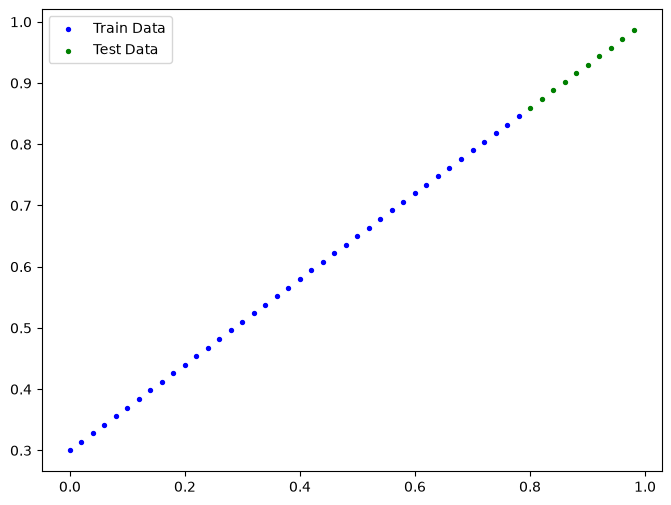

In [29]:
plot_prediction()

## 2. Build a Model

In [8]:
class LinearRegressionModelV1(nn.Module):

    def __init__(self):
        super().__init__()

        self.weights = nn.Parameter(torch.randn(1, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, dtype=torch.float))

    def forward(self, x):

        return self.weights * x + self.bias


model1 = LinearRegressionModelV1()
model1

LinearRegressionModelV1()

## PyTorch model build essential

PyTouch gives you to build model like neural network.

*They are :*
1. `torch.nn`
2. `torch.optim`
3. `torch.utils.data.Dataset`
4. `torch.utils.data.DataLoader`

In [9]:
torch.manual_seed(42)

list(model1.parameters())

[Parameter containing:
 tensor([0.3115], requires_grad=True),
 Parameter containing:
 tensor([-0.7886], requires_grad=True)]

In [10]:
model1.state_dict()

OrderedDict([('weights', tensor([0.3115])), ('bias', tensor([-0.7886]))])

Make predictions with `torch.inference_mode()`

In [13]:
with torch.inference_mode():
    y_preds = model1(X_test)

y_preds

tensor([[-0.5394],
        [-0.5332],
        [-0.5269],
        [-0.5207],
        [-0.5145],
        [-0.5082],
        [-0.5020],
        [-0.4958],
        [-0.4895],
        [-0.4833]])

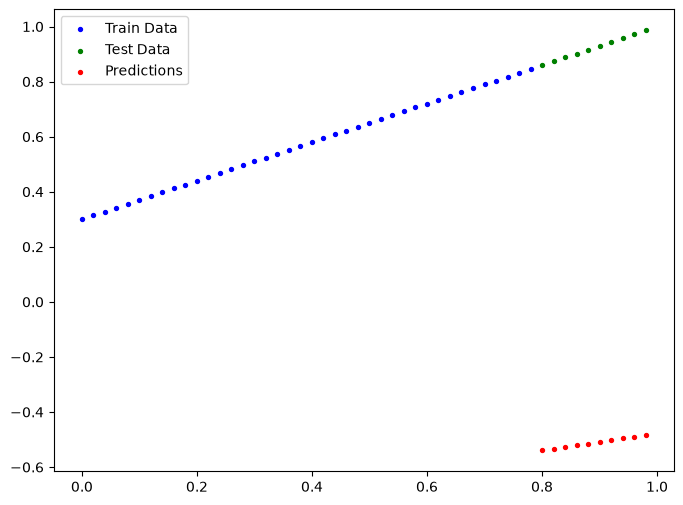

In [30]:
plot_prediction(pred_data=y_preds);

## 3. Train Model

In [31]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model1.parameters(), lr=0.01)

In [42]:
torch.manual_seed(42)

epochs = 100

train_loss_values = []
test_loss_values = []
epoch_counts = []

for epoch in range(epochs):

    model1.train()

    y_preds = model1(X_train)

    loss = loss_fn(y_preds, y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model1.eval()

    with torch.inference_mode():
        test_pred = model1(X_test)

        test_loss = loss_fn(test_pred, y_test.type(torch.float))

    if epoch % 10 == 0:
        
        print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

        train_loss_values.append(loss.detach().numpy())
        test_loss_values.append(test_loss.detach().numpy())
        epoch_counts.append(epoch)

Epoch: 0 | MAE Train Loss: 0.008978917263448238 | MAE Test Loss: 0.005251693539321423 
Epoch: 10 | MAE Train Loss: 0.008978917263448238 | MAE Test Loss: 0.005251693539321423 
Epoch: 20 | MAE Train Loss: 0.008978917263448238 | MAE Test Loss: 0.005251693539321423 
Epoch: 30 | MAE Train Loss: 0.008978917263448238 | MAE Test Loss: 0.005251693539321423 
Epoch: 40 | MAE Train Loss: 0.008978917263448238 | MAE Test Loss: 0.005251693539321423 
Epoch: 50 | MAE Train Loss: 0.008978917263448238 | MAE Test Loss: 0.005251693539321423 
Epoch: 60 | MAE Train Loss: 0.008978917263448238 | MAE Test Loss: 0.005251693539321423 
Epoch: 70 | MAE Train Loss: 0.008978917263448238 | MAE Test Loss: 0.005251693539321423 
Epoch: 80 | MAE Train Loss: 0.008978917263448238 | MAE Test Loss: 0.005251693539321423 
Epoch: 90 | MAE Train Loss: 0.008978917263448238 | MAE Test Loss: 0.005251693539321423 


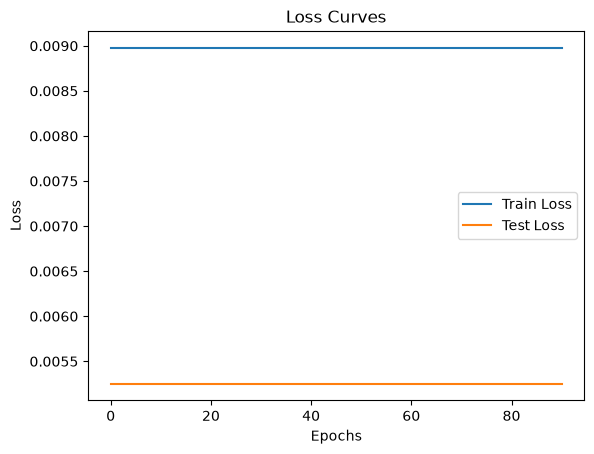

In [47]:
plt.plot(epoch_counts, train_loss_values, label='Train Loss')
plt.plot(epoch_counts, test_loss_values, label='Test Loss')
plt.title('Loss Curves')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend();

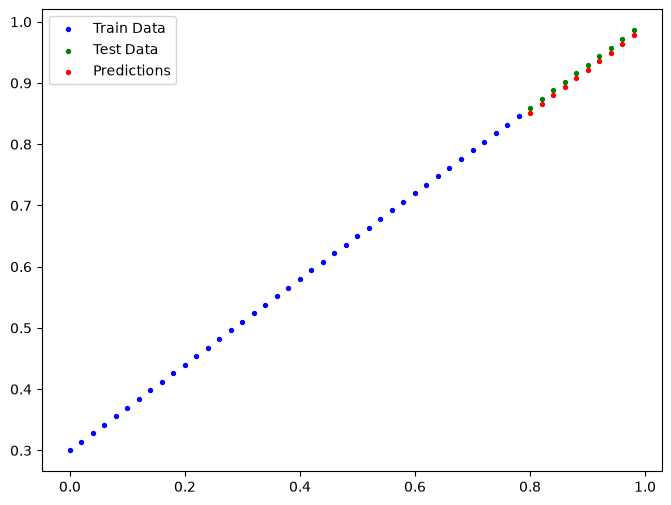

In [49]:
model1.eval()
with torch.inference_mode():
    y_preds = model1(X_test)

plot_prediction(pred_data=y_preds)

In [52]:
model1.state_dict()

OrderedDict([('weights', tensor([0.7015])), ('bias', tensor([0.2904]))])

## Saving and loading a PyTorch model

In [56]:
from pathlib import Path

MODEL_PATH = Path('models')
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = 'linearmodelv1.pth'

MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME
torch.save(obj=model1.state_dict(), f=MODEL_SAVE_PATH)

In [57]:
loaded_model = LinearRegressionModelV1()

loaded_model.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

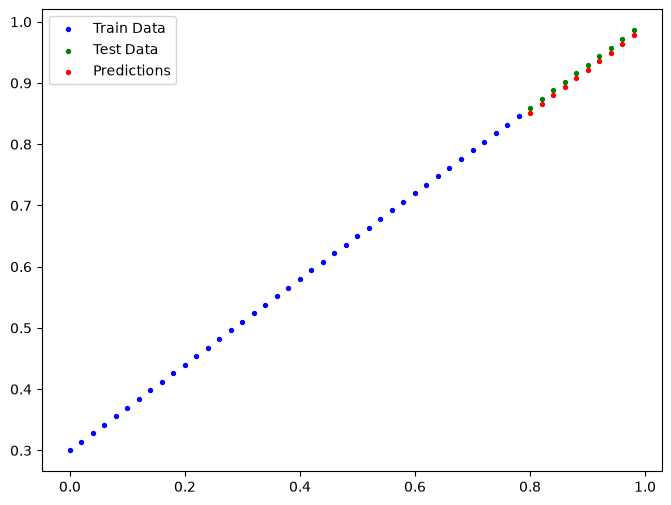

In [60]:
loaded_model.eval()
with torch.inference_mode():
    loaded_preds = loaded_model(X_test)

plot_prediction(pred_data=loaded_preds);